<a href="https://colab.research.google.com/github/nadjmif/StatsDeskriptif/blob/main/Nadjmi_StatDeskriptif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# baca file, header lama hilangkan
df = pd.read_excel('stat.xlsx', header=1)
df = df.iloc[:, 1:]  # buang kolom pertama yang kosong
df.columns = ["NIM", "Nama", "Kuis", "UTS", "UAS", "Nilai_Akhir", "Grade"]

# Deskripsi
print(df)
print(f"Jumlah mahasiswa: {len(df)}")

       NIM                Nama  Kuis  UTS  UAS  Nilai_Akhir Grade
0   120001            John Doe    85   78   90        84.65     A
1   120005          Jane Smith    92   88   94        91.50     A
2   120017     Michael Johnson    48   65   56        55.90     C
3   120018         Emily Brown    90   85   88        87.80     A
4   120022     Daniel Martinez    75   80   77        77.20    AB
5   120024        Sarah Wilson    88   70   65        74.55     B
6   120025        David Garcia    75   70   75        73.50     B
7   120027         Jessica Lee    95   91   96        94.15     A
8   120034       Matthew Davis    79   84   78        80.15    AB
9   120035  Jennifer Rodriguez    42   48   63        51.15     C
10  120036       Andrew Taylor    53   64   59        58.40     C
11  120038    Amanda Hernandez    91   95   90        91.85     A
12  120039   Christopher Clark    76   81   75        77.15    AB
13  120046  Elizabeth Martinez    89   93   88        89.85     A
14  120047

In [6]:
#Tabel Frekuensi
urutan_grade = ["A", "AB", "B", "BC", "C", "F"]

tabel_frekuensi = pd.crosstab(index=df["Grade"], columns="Frekuensi")
tabel_frekuensi = tabel_frekuensi.reindex(urutan_grade)

frek = df["Grade"].value_counts().reindex(urutan_grade).fillna(0).astype(int)
persen = (frek / frek.sum() * 100).round(0).astype(int)

tabel_frek = pd.DataFrame({"Frekuensi": frek, "Persentase": persen})
tabel_frek.loc["Total"] = [frek.sum(), 100]

print(tabel_frek)

       Frekuensi  Persentase
Grade                       
A             12          40
AB             7          23
B              4          13
BC             1           3
C              5          17
F              1           3
Total         30         100


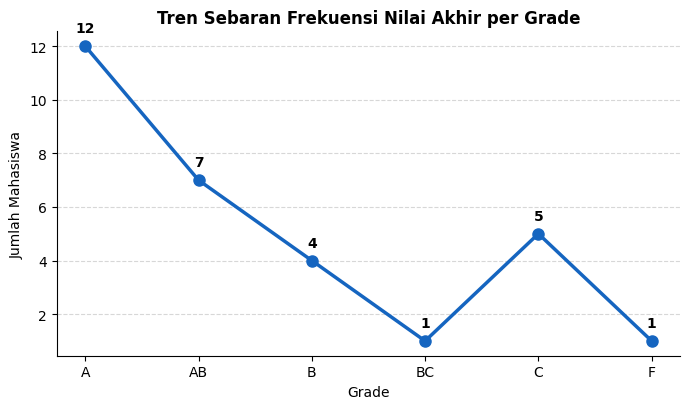

In [7]:
#Visualisasi
palet = ["#2E7D32", "#66BB6A", "#FFB300", "#FB8C00", "#E53935", "#B71C1C"]
plt.rcParams["font.family"] = "DejaVu Sans"

# Grafik Garis
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(urutan_grade, frek.values, marker="o", markersize=8, linewidth=2.5, color="#1565C0")
for x, y in zip(urutan_grade, frek.values):
    ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10, fontweight="bold")
ax.set_title("Tren Sebaran Frekuensi Nilai Akhir per Grade", fontsize=12, fontweight="bold")
ax.set_xlabel("Grade")
ax.set_ylabel("Jumlah Mahasiswa")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

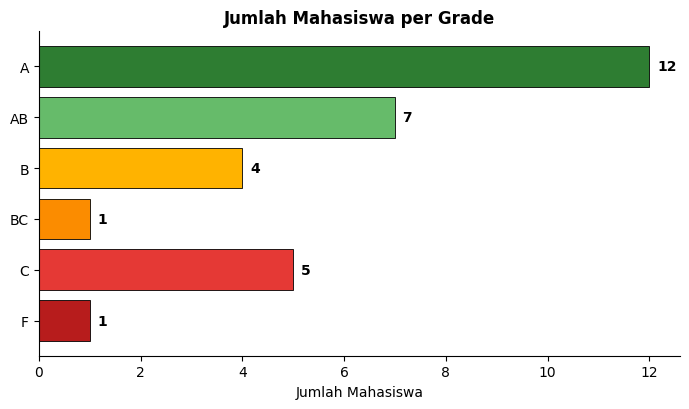

In [8]:
# Grafik Batang
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.barh(urutan_grade[::-1], frek.values[::-1], color=palet[::-1],
                edgecolor="black", linewidth=0.6)
for bar, val in zip(bars, frek.values[::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=10, fontweight="bold")
ax.set_title("Jumlah Mahasiswa per Grade", fontsize=12, fontweight="bold")
ax.set_xlabel("Jumlah Mahasiswa")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

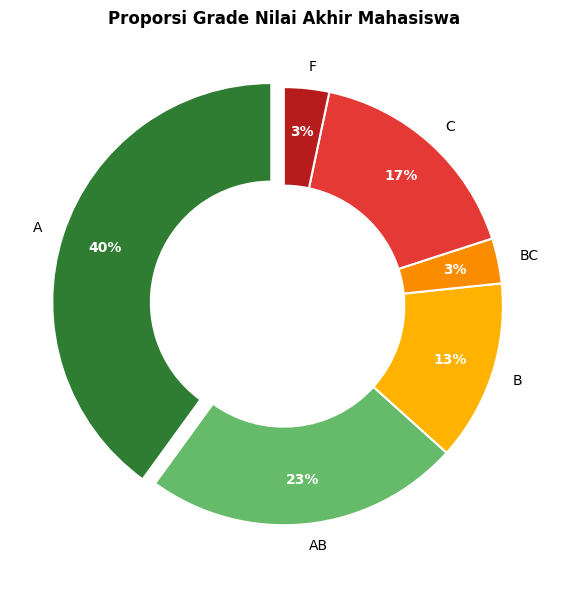

In [9]:
# Pie Chart (grade terbanyak ditonjolkan)
fig, ax = plt.subplots(figsize=(6, 6))
explode = [0.06 if g == frek.idxmax() else 0 for g in urutan_grade]
wedges, texts, autotexts = ax.pie(
    frek.values, labels=urutan_grade, autopct="%1.0f%%", startangle=90,
    colors=palet, explode=explode, pctdistance=0.8,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.5),
)
for t in autotexts:
    t.set_fontweight("bold")
    t.set_color("white")
ax.set_title("Proporsi Grade Nilai Akhir Mahasiswa", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
#Statistika Deskriptif
dt = df["Nilai_Akhir"]

stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"] = dt.median()
stats["Mode"] = dt.mode().iloc[0]
stats["Variance"] = dt.var()
stats["Range"] = dt.max() - dt.min()
stats["Skewness"] = dt.skew()
stats["Kurtosis"] = dt.kurtosis()

q1, q3 = dt.quantile(.25), dt.quantile(.75)
iqr = q3 - q1
batas_bawah = q1 - 1.5 * iqr
batas_atas = q3 + 1.5 * iqr
outlier = dt[(dt < batas_bawah) | (dt > batas_atas)]

print("\nStatistika Deskriptif")
print(stats.round(2))
print(f"\nIQR (Q3-Q1)     : {iqr:.2f}")
print(f"Batas bawah IQR : {batas_bawah:.2f}")
print(f"Batas atas IQR  : {batas_atas:.2f}")
print(f"Outlier         : {list(outlier) if len(outlier) else 'tidak ada'}")


Statistika Deskriptif
count              30.00
mean               76.19
std                13.51
min                45.65
25%                68.20
50%                78.65
75%                86.95
max                94.15
Standard Error      2.47
Median             78.65
Mode               77.15
Variance          182.39
Range              48.50
Skewness           -0.67
Kurtosis           -0.49
Name: Nilai_Akhir, dtype: float64

IQR (Q3-Q1)     : 18.75
Batas bawah IQR : 40.07
Batas atas IQR  : 115.08
Outlier         : tidak ada
